<a href="https://colab.research.google.com/github/vanira0/deepfakedetection/blob/main/BTP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import json
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [ ]:
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [ ]:
# Parameters
input_shape = (128, 128, 3)
num_frames = 5  # Number of frames per video
real_data_dir = 'D:/Projects/Deepfake project/archive/Sub_Dataset/real1'
fake_data_dir = 'D:/Projects/Deepfake project/archive/Sub_Dataset/fake1'

# Load real and fake image file names
real_data = sorted([f for f in os.listdir(real_data_dir) if f.endswith('.png')])
fake_data = sorted([f for f in os.listdir(fake_data_dir) if f.endswith('.png')])

print("Number of real images:", len(real_data))
print("Number of fake images:", len(fake_data))

# Ensure the total number of images is divisible by `num_frames`
real_data = real_data[:len(real_data) - len(real_data) % num_frames]
fake_data = fake_data[:len(fake_data) - len(fake_data) % num_frames]

# Initialize arrays
X = []
Y = []

# Load real images
for i in range(0, len(real_data), num_frames):
    frames = []
    for img in real_data[i:i + num_frames]:
        img_array = img_to_array(load_img(os.path.join(real_data_dir, img), target_size=input_shape)).astype('float32') / 127.0
        frames.append(img_array)
    X.append(frames)
    Y.append(1)  # Label for real video

# Load fake images
for i in range(0, len(fake_data), num_frames):
    frames = []
    for img in fake_data[i:i + num_frames]:
        img_array = img_to_array(load_img(os.path.join(fake_data_dir, img), target_size=input_shape)).astype('float32') / 127.0
        frames.append(img_array)
    X.append(frames)
    Y.append(0)  # Label for fake video

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

print("Shape of X before one-hot encoding:", X.shape)  # (num_videos, num_frames, 256, 256, 3)
print("Shape of Y before one-hot encoding:", Y.shape)  # (num_videos,)

# Normalize labels
Y = to_categorical(Y, 2)

print("Shape of X after reshaping:", X.shape)
print("Shape of Y after one-hot encoding:", Y.shape)

# Train-Test split
X_train_, X_val_, Y_train_, Y_val_ = train_test_split(X, Y, test_size=0.2, random_state=5)

print("Shape of X_train_:", X_train_.shape)  # (num_train_videos, num_frames, 256, 256, 3)
print("Shape of X_val_:", X_val_.shape)    # (num_val_videos, num_frames, 256, 256, 3)
print("Shape of Y_train_:", Y_train_.shape)  # (num_train_videos, 2)
print("Shape of Y_val_:", Y_val_.shape)    # (num_val_videos, 2)

Number of real images: 500
Number of fake images: 500
Shape of X before one-hot encoding: (200, 5, 128, 128, 3)
Shape of Y before one-hot encoding: (200,)
Shape of X after reshaping: (200, 5, 128, 128, 3)
Shape of Y after one-hot encoding: (200, 2)
Shape of X_train_: (160, 5, 128, 128, 3)
Shape of X_val_: (40, 5, 128, 128, 3)
Shape of Y_train_: (160, 2)
Shape of Y_val_: (40, 2)


In [ ]:
# def augment_data(X, Y):
#     augmented_X = []
#     for video in X:
#         augmented_frames = []
#         for frame in video:
#             frame = np.expand_dims(frame, axis=0)  # Add batch dimension
#             augmented_frame = next(datagen.flow(frame, batch_size=1, shuffle=False))[0]
#             augmented_frames.append(augmented_frame)
#         augmented_X.append(np.array(augmented_frames))
#     return np.array(augmented_X), Y

# X_train_, Y_train_ = augment_data(X_train_, Y_train_)

# print("Shape of X_train_:", X_train_.shape)  # (num_train_videos, num_frames, 256, 256, 3)
# print("Shape of X_val_:", X_val_.shape)    # (num_val_videos, num_frames, 256, 256, 3)
# print("Shape of Y_train_:", Y_train_.shape)  # (num_train_videos, 2)
# print("Shape of Y_val_:", Y_val_.shape)    # (num_val_videos, 2)

Shape of X_train_: (160, 5, 128, 128, 3)
Shape of X_val_: (40, 5, 128, 128, 3)
Shape of Y_train_: (160, 2)
Shape of Y_val_: (40, 2)


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, TimeDistributed, GRU, Input, Dropout, MaxPooling2D, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Parameters
num_frames = 5
frame_height, frame_width = 128, 128
channels = 3
input_shape = (num_frames, frame_height, frame_width, channels)
BATCH_SIZE = 4
EPOCHS = 10

# Input layer
video_input = Input(shape=input_shape, name='video_input')

# Base CNN (EfficientNetB0)
base_cnn = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(frame_height, frame_width, channels))
base_cnn.trainable = True  # Allow fine-tuning

# Feature extraction for each frame
encoded_frames = TimeDistributed(base_cnn, name='efficientnet')(video_input)

# Multi-scale feature extraction
def multi_scale_features(x):
    # Small pooling
    x_small = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(x)
    x_small = TimeDistributed(Flatten())(x_small)  # Flatten to prepare for concatenation

    # Large pooling
    x_large = TimeDistributed(MaxPooling2D(pool_size=(4, 4)))(x)
    x_large = TimeDistributed(Flatten())(x_large)  # Flatten to prepare for concatenation

    # Flatten original feature maps
    x = TimeDistributed(Flatten())(x)

    # Concatenate
    x_combined = Concatenate()([x, x_small, x_large])
    return x_combined

# Apply multi-scale features
encoded_frames = multi_scale_features(encoded_frames)  # Shape: (batch_size, num_frames, feature_vector_size)

# GRU for temporal dependencies
gru_out = GRU(units=64, return_sequences=False, name='gru')(encoded_frames)

# Fully connected layers
dense_1 = Dense(16, activation='relu', name='dense_1')(gru_out)
dense_1 = Dropout(0.3)(dense_1)
output = Dense(units=2, activation='softmax', name='output')(dense_1)

# Assuming Y_train_ is one-hot encoded, convert it to integer labels
if Y_train_.ndim == 2 and Y_train_.shape[1] == 2:
    y_int = np.argmax(Y_train_, axis=1)
else:
    y_int = Y_train_

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_int), y=y_int)
print(f"Class weights: {class_weights}")

# Convert class weights to tensor
class_weights_tensor = K.constant(class_weights, dtype=K.floatx())

# Define the weighted categorical crossentropy loss
def weighted_categorical_crossentropy(class_weights_tensor):
    def loss(y_true, y_pred):
        y_true = K.cast(y_true, y_pred.dtype)  # Ensure dtype compatibility
        weights = y_true * class_weights_tensor  # Multiply true labels by class weights
        weights = K.sum(weights, axis=-1)  # Sum weights per sample
        cce = K.categorical_crossentropy(y_true, y_pred)
        return cce * weights
    return loss

# Define and compile the model
model = Model(inputs=video_input, outputs=output, name='EfficientNetB0_GRU_Hybrid')
model.compile(
    loss=weighted_categorical_crossentropy(class_weights_tensor),
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

model.summary()

Class weights: [0.97560976 1.02564103]


Model: "EfficientNetB0_GRU_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ video_input         │ (None, 5, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet        │ (None, 5, 4, 4,   │  4,049,571 │ video_input[0][0] │
│ (TimeDistributed)   │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_43 │ (None, 5, 2, 2,   │          0 │ efficientnet[0][… │
│ (TimeDistributed)   │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_45 │ (None, 5, 1, 1,   │          0 │ efficientnet[0][… │
│ (TimeDistributed)   │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_47 │ (None, 5, 20480)  │          0 │ efficientnet[0][… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_44 │ (None, 5, 5120)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_46 │ (None, 5, 1280)   │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 5, 26880)  │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │  5,173,632 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │      1,040 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │         34 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,224,277 (35.19 MB)

 Trainable params: 9,182,254 (35.03 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Training parameters
EPOCHS = 25
BATCH_SIZE = 8

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Training
history = model.fit(
    X_train_, Y_train_,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_, Y_val_),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.4286 - loss: 0.7574 - val_accuracy: 0.6000 - val_loss: 0.6628
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6107 - loss: 0.6321 - val_accuracy: 0.5750 - val_loss: 0.6526
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7124 - loss: 0.5221 - val_accuracy: 0.6750 - val_loss: 0.5849
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7157 - loss: 0.5080 - val_accuracy: 0.6000 - val_loss: 0.6402
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7163 - loss: 0.5167 - val_accuracy: 0.7500 - val_loss: 0.6348
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8813 - loss: 0.2918 - val_accuracy: 0.7750 - val_loss: 0.5741
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.9073 - loss: 0.2325 - val_accuracy: 0.4250 - val_loss: 0.7919
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9303 - loss: 0.2060 - val_accuracy: 0.5750 - val_loss

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 495ms/step - accuracy: 0.5523 - loss: 0.7099 - val_accuracy: 0.6500 - val_loss: 0.6783
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.5095 - loss: 0.7271 - val_accuracy: 0.6750 - val_loss: 0.6606
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.6145 - loss: 0.6816 - val_accuracy: 0.6250 - val_loss: 0.6171
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.6144 - loss: 0.6338 - val_accuracy: 0.7250 - val_loss: 0.6176
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.7410 - loss: 0.6134 - val_accuracy: 0.7750 - val_loss: 0.5854
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.6758 - loss: 0.5923 - val_accuracy: 0.7750 - val_loss: 0.5483
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.7144 - loss: 0.5808 - val_accuracy: 0.8500 - val_loss: 0.5411
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.7407 - loss: 0.5672 - val_accuracy: 0

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on validation data
y_pred_prob = model.predict(X_val_)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(Y_val_, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred))


2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 11s/step
Confusion Matrix:
[[16  2]
 [ 7 15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.89      0.78        18
           1       0.88      0.68      0.77        22

    accuracy                           0.78        40
   macro avg       0.79      0.79      0.77        40
weighted avg       0.80      0.78      0.77        40



2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step
Accuracy: 0.7750
Precision: 0.8824
Recall: 0.6818
F1-Score: 0.7692
AUC-ROC: 0.8384
Confusion Matrix:
 [[16  2]
 [ 7 15]]


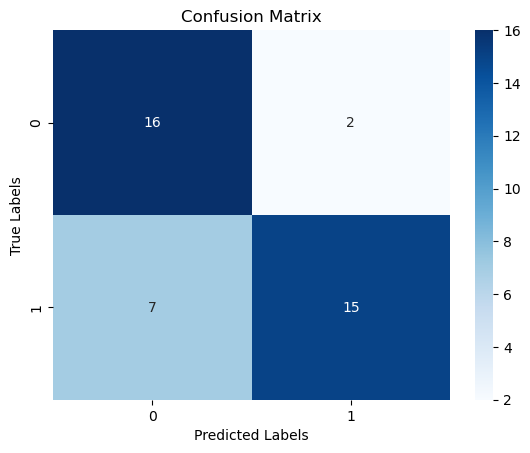

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
Y_pred_proba = model.predict(X_val_)
# Predicted classes
Y_pred = np.argmax(Y_pred_proba, axis=1)
# True classes
Y_true = np.argmax(Y_val_, axis=1)

# Compute metrics
accuracy = accuracy_score(Y_true, Y_pred)
precision = precision_score(Y_true, Y_pred, average='binary')
recall = recall_score(Y_true, Y_pred, average='binary')
f1 = f1_score(Y_true, Y_pred, average='binary')
auc_roc = roc_auc_score(Y_val_, Y_pred_proba, multi_class='ovr')

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(Y_true, Y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Plot confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

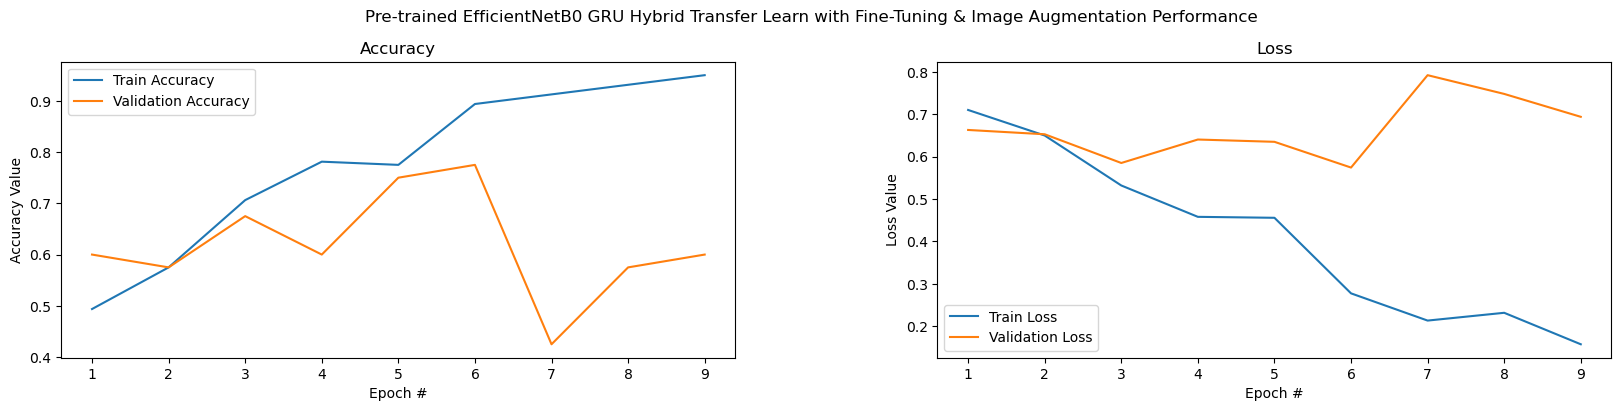

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
t = f.suptitle('Pre-trained EfficientNetB0 GRU Hybrid Transfer Learn with Fine-Tuning & Image Augmentation Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

# Use the actual number of epochs recorded in history
epoch_list = list(range(1, len(history.history['accuracy']) + 1))

# Plot accuracy
ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(np.arange(1, len(epoch_list) + 1, 1))
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch #')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

# Plot loss
ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')
ax2.set_xticks(np.arange(1, len(epoch_list) + 1, 1))
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch #')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")

plt.show()
